In [1]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [4]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['country'].isin(leetcode_questions_df['country'].value_counts().head(2).index)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12612 entries, 64 to 61803
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            12612 non-null  object 
 1   country                             12612 non-null  object 
 2   contest_url                         12612 non-null  object 
 3   num_of_contest                      12612 non-null  int64  
 4   is_weekly                           12612 non-null  bool   
 5   rank                                12612 non-null  int64  
 6   score                               12612 non-null  int64  
 7   question_number                     12612 non-null  int64  
 8   question_language                   12612 non-null  object 
 9   question_code                       12612 non-null  object 
 10  number_of_lines                     12612 non-null  int64  
 11  names_set                           12612 non

In [5]:
leetcode_questions_df.country.value_counts()

,count
country,
India,10865
United States,1747


In [6]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,...,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000
mean,277.618141,611.223834,16.170076,3.419521,51.672772,41.744291,20.769981,2.042975,3.360054,4.487076,...,0.047276,0.087194,0.113584,0.093314,3667.123137,2644.153742,1270.423327,0.034219,1392.486917,6.444656
std,126.184909,344.512547,2.757681,0.493500,34.843605,24.781130,10.210378,2.563672,2.982278,3.670287,...,0.026540,0.074018,0.077667,0.163232,1509.153943,1323.634070,975.268882,0.072692,939.893144,5.669011
min,117.000000,1.000000,8.000000,3.000000,6.000000,10.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,297.000000,99.000000,0.000000,0.000001,107.000000,1.000000
25%,123.000000,320.000000,13.000000,3.000000,31.000000,29.000000,15.000000,1.000000,1.000000,2.000000,...,0.029412,0.035714,0.058824,0.000000,2481.000000,1539.000000,552.000000,0.002230,824.000000,2.000000
50%,371.000000,610.000000,18.000000,3.000000,44.000000,36.000000,18.000000,1.000000,3.000000,4.000000,...,0.040000,0.075472,0.103448,0.000000,3618.000000,2496.500000,1035.500000,0.008753,1203.000000,5.000000
75%,383.000000,901.250000,18.000000,4.000000,63.000000,45.000000,24.000000,2.000000,5.000000,6.000000,...,0.058824,0.117647,0.152542,0.142857,4872.000000,3639.000000,1804.000000,0.030834,1710.000000,9.000000
max,390.000000,1225.000000,20.000000,4.000000,1026.000000,307.000000,152.000000,58.000000,98.000000,105.000000,...,0.407407,1.673913,1.434783,1.000000,9359.000000,5399.000000,5254.000000,1.000000,21789.000000,29.000000


In [7]:
model_name = "neulab/codebert-cpp"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = leetcode_questions_df.question_code.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-cpp and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [8]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

1000

In [9]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.05, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 2784 outliers.
Retained 9828 code snippets.


In [10]:
# Remove outliers from the DataFrame
leetcode_questions_df.reset_index(drop=True, inplace=True)
leetcode_questions_df = leetcode_questions_df[~leetcode_questions_df.index.isin(outliers)]

leetcode_questions_df.country.value_counts()

,count
country,
India,8582
United States,1246


In [11]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [12]:
X.question_number = X.question_number.astype("category")

In [13]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [14]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [15]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [16]:
num_labels = len(enc.classes_)
num_labels

2

In [20]:
llm_df = pd.read_csv('/content/C___Code_Classification_by_Country.csv')

In [21]:
y_test_llm = enc.transform(llm_df.predicted_country)

In [22]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

               precision    recall  f1-score   support

        India       0.88      0.11      0.19      1717
United States       0.13      0.90      0.22       249

     accuracy                           0.21      1966
    macro avg       0.50      0.50      0.21      1966
 weighted avg       0.78      0.21      0.19      1966

f1_score_macro :  0.20562202279031927
f1_score_weighted :  0.19264859676731172


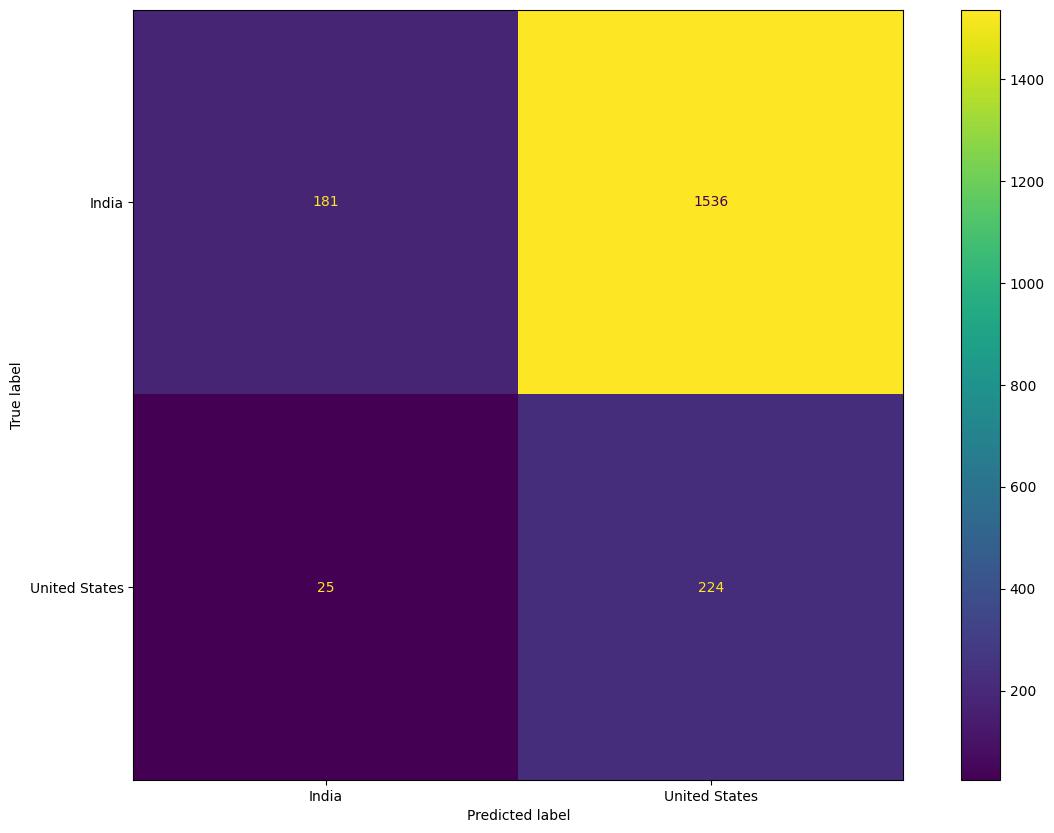

In [23]:
print(classification_report(y_test, y_test_llm, target_names=enc.classes_))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm), display_labels=enc.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()